# PROJECT TITLE-UNLOCKING CUSTOMER INSIGHTS: A STATISTICAL INVESTIGATION

## Problem Statement

A mid-sized Indian retail company is sitting on a treasure trove of customer data — but
lacks clarity on what story it tells. They need a team of analysts to conduct a rigorous
statistical investigation to validate business assumptions, uncover hidden patterns, and
support data-driven decision-making

## Data Dictionary

***CustomerID***: Unique identifier for each customer

***Name***: Full name of the customer (US names used)

***State***: US state where the customer resides

***Education***: Highest level of education attained (High School to PhD)

***Gender***: Gender identity (Male, Female, Non-Binary)

***Age***: Age of the customer (between 18 and 80)

***Married***: Marital status: Yes or No

***NumPets***: Number of pets owned by the customer (0 to 4)

***MonthlySpend***: Amount spent monthly in USD, generated using a skewed Gamma distribution

***DaysSinceLastInteraction***: Number of days since last interaction with the company

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr
import warnings
warnings.filterwarnings('ignore')

## Data Preparation

In [2]:
#loading the data
df_customers=pd.read_csv("US_Customer_Insights_Dataset.csv")

## STEP 1: Understanding The Data

In [3]:
#top 5 records
print("="*110)
print("The first five records from the US_Customer_Insights_Dataset is listed below")
print("="*110)
df_customers.head()

The first five records from the US_Customer_Insights_Dataset is listed below


,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


***OUTPUT INSIGHT- Here we can have a look at the first five records of the dataset***

In [4]:
# Getting the number of rows and columns present in the dataset

In [5]:
print("="*100)
print("US_Customer_Insight Dataset")
print("="*30)
print("Total number of customers and data points collected in the US_Customer_Insight Dataset:", df_customers.shape)
print("="*100)

US_Customer_Insight Dataset
Total number of customers and data points collected in the US_Customer_Insight Dataset: (10675, 12)


***OUTPUT INSIGHT: In the dataset we have 10675 rows and 12 columns, containing customer information such as CustomerID ,name, state, education, gender, age, marital status,number of pets, monthly spend and days since last transaction.***

In [6]:
# Understanding the categories of data present in the dataset

In [7]:
print("="*70)
print("US_Customer_Insight Dataset")
print("="*70)
print("\nOverview of the data categories and types in US_Customer_Insight Dataset:")
print(df_customers.info())
print("="*70)

US_Customer_Insight Dataset

Overview of the data categories and types in US_Customer_Insight Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1)

***OUTPUT INSIGHTS: Here we can see the the number of non null records and datatypes of each column where its clear that the join date column and transaction date column are not in the proper date format which has to fixed for further analysis***

In [8]:
# Understanding the statistical summary of the dataset

In [9]:
print("="*70)
print("US_Customer_Insight Dataset")
print("="*70)
print("Here is the statistical summary of US_Customer_Insight Dataset:\n",df_customers.describe())
print("="*70)

US_Customer_Insight Dataset
Here is the statistical summary of US_Customer_Insight Dataset:
                 Age       NumPets  MonthlySpend  DaysSinceLastInteraction
count  10675.000000  10675.000000  10675.000000              10675.000000
mean      49.474567      1.340515    331.610315                538.469883
std       18.221365      1.150849    225.799253                398.766747
min       18.000000      0.000000      3.890000                  1.000000
25%       35.000000      0.000000    165.495000                218.000000
50%       49.000000      1.000000    282.110000                445.000000
75%       66.000000      2.000000    443.255000                788.500000
max       80.000000      4.000000   1740.420000               1791.000000


***OUTPUT INSIGHT: Here we have the statistical summary of the dataset viz. the mean, median mode, standard deviation are being calculated***

In [10]:
# Total number of elemets present in the datasets

In [11]:
print("total number of elemets present in the US_Customer_Insight Dataset:\n",df_customers.size)

total number of elemets present in the US_Customer_Insight Dataset:
 128100


***OUTPUT INSIGHT: The dataset has 128100 records in total***

In [12]:
# Columns present in the dataset

In [13]:
print("All columns present in the US_Customer_Insight Dataset are:\n",df_customers.columns)

All columns present in the US_Customer_Insight Dataset are:
 Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction'],
      dtype='object')


***OUTPUT INSIGHT- The list of all columns present in the US_Customer_Insight Dataset is shown here***

In [14]:
# Understanding the data types of each column present in the datasets and separating them according to their datatypes

In [15]:
print("="*70)
print("US_Customer_Insight Dataset")
print("="*70)
print("Datatypes of each column in the US_Customer_Insight Dataset:\n", df_customers.dtypes)
#separating on the basis of the datatypes present
    #list of numerical column names 
print("="*70)
print("list of numerical columns present in the US_Customer_Insight Dataset:\n",df_customers.select_dtypes(include=["number"]).columns)
print("="*70)
    #list of categorical column names
print("="*70)
print("list of categorical columns present in the US_Customer_Insight Dataset:\n",df_customers.select_dtypes(exclude=["number"]).columns)
print("="*70)

US_Customer_Insight Dataset
Datatypes of each column in the US_Customer_Insight Dataset:
 CustomerID                   object
Name                         object
State                        object
Education                    object
Gender                       object
Age                           int64
Married                      object
NumPets                       int64
JoinDate                     object
TransactionDate              object
MonthlySpend                float64
DaysSinceLastInteraction      int64
dtype: object
list of numerical columns present in the US_Customer_Insight Dataset:
 Index(['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction'], dtype='object')
list of categorical columns present in the US_Customer_Insight Dataset:
 Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Married',
       'JoinDate', 'TransactionDate'],
      dtype='object')


***OUTPUT INSIGHT: Here we can have a look into the datatypes of the columns present in the datasets and its clear from the output that some of the date columns viz. join date and transaction date have incorrect type data and has to be converted into proper date format for further analysis***

## DATA CLEANING

#### FIXING DATE COLUMNS

In [16]:
# Fixing Join Date column
df_customers["JoinDate"]=pd.to_datetime(df_customers["JoinDate"])

In [17]:
#Fixing Transaction Date columns
df_customers['TransactionDate']=pd.to_datetime(df_customers['TransactionDate'])

In [18]:
df_customers[["JoinDate","TransactionDate"]].dtypes

JoinDate           datetime64[ns]
TransactionDate    datetime64[ns]
dtype: object

***OUTPUT INSIGHT: The Join date and Transaction date columns which had incorrect data types are being fixed now further analysis can be continued***

#### MISSING VALUES TREATMENT

In [19]:
df_customers.isna().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

***OUTPUT INSIGHT: The dataset has no missing values and further analysis can be continued***

#### CHECKING FOR DUPLICATE VALUES

In [20]:
df_customers.duplicated().sum()

np.int64(0)

***OUTPUT INSIGHT: The dataset has no duplicate values and further analysis can be continued***

#### CHECKING FOR UNIQUE RECORDS IN THE CUSTOMER ID COLUMN

In [21]:
list_customerid_unique=df_customers['CustomerID'].unique()
df_customers['CustomerID'].nunique()

1000

***OUTPUT INSIGHT: There are 1000 unique customer ids in the column***

## STEP 2: DESCRIPTIVE STATISTICS

In [22]:
#Mean, Median and Standard deviation
df_customers[['Age','MonthlySpend','DaysSinceLastInteraction']].agg(['mean','median','std'])

,Age,MonthlySpend,DaysSinceLastInteraction
mean,49.474567,331.610315,538.469883
median,49.000000,282.110000,445.000000
std,18.221365,225.799253,398.766747


In [23]:
df_customers[["Gender","Education","Married"]].mode()

,Gender,Education,Married
0,Male,Master,No


***OUTPUT INSIGHTS: Most of the customers are around 49 years old, so the company mainly serves middle-aged people. On average, customers spend about 332 per month, but many spend around 282, which means a few customers spend much more than others. Customers have not interacted with the company for a long time on average (around 538 days), which suggests many customers may not be very active.The most common type of customer is a male, with a Master’s degree, and not married.***

## STEP 3: DATA VISUALIZATION

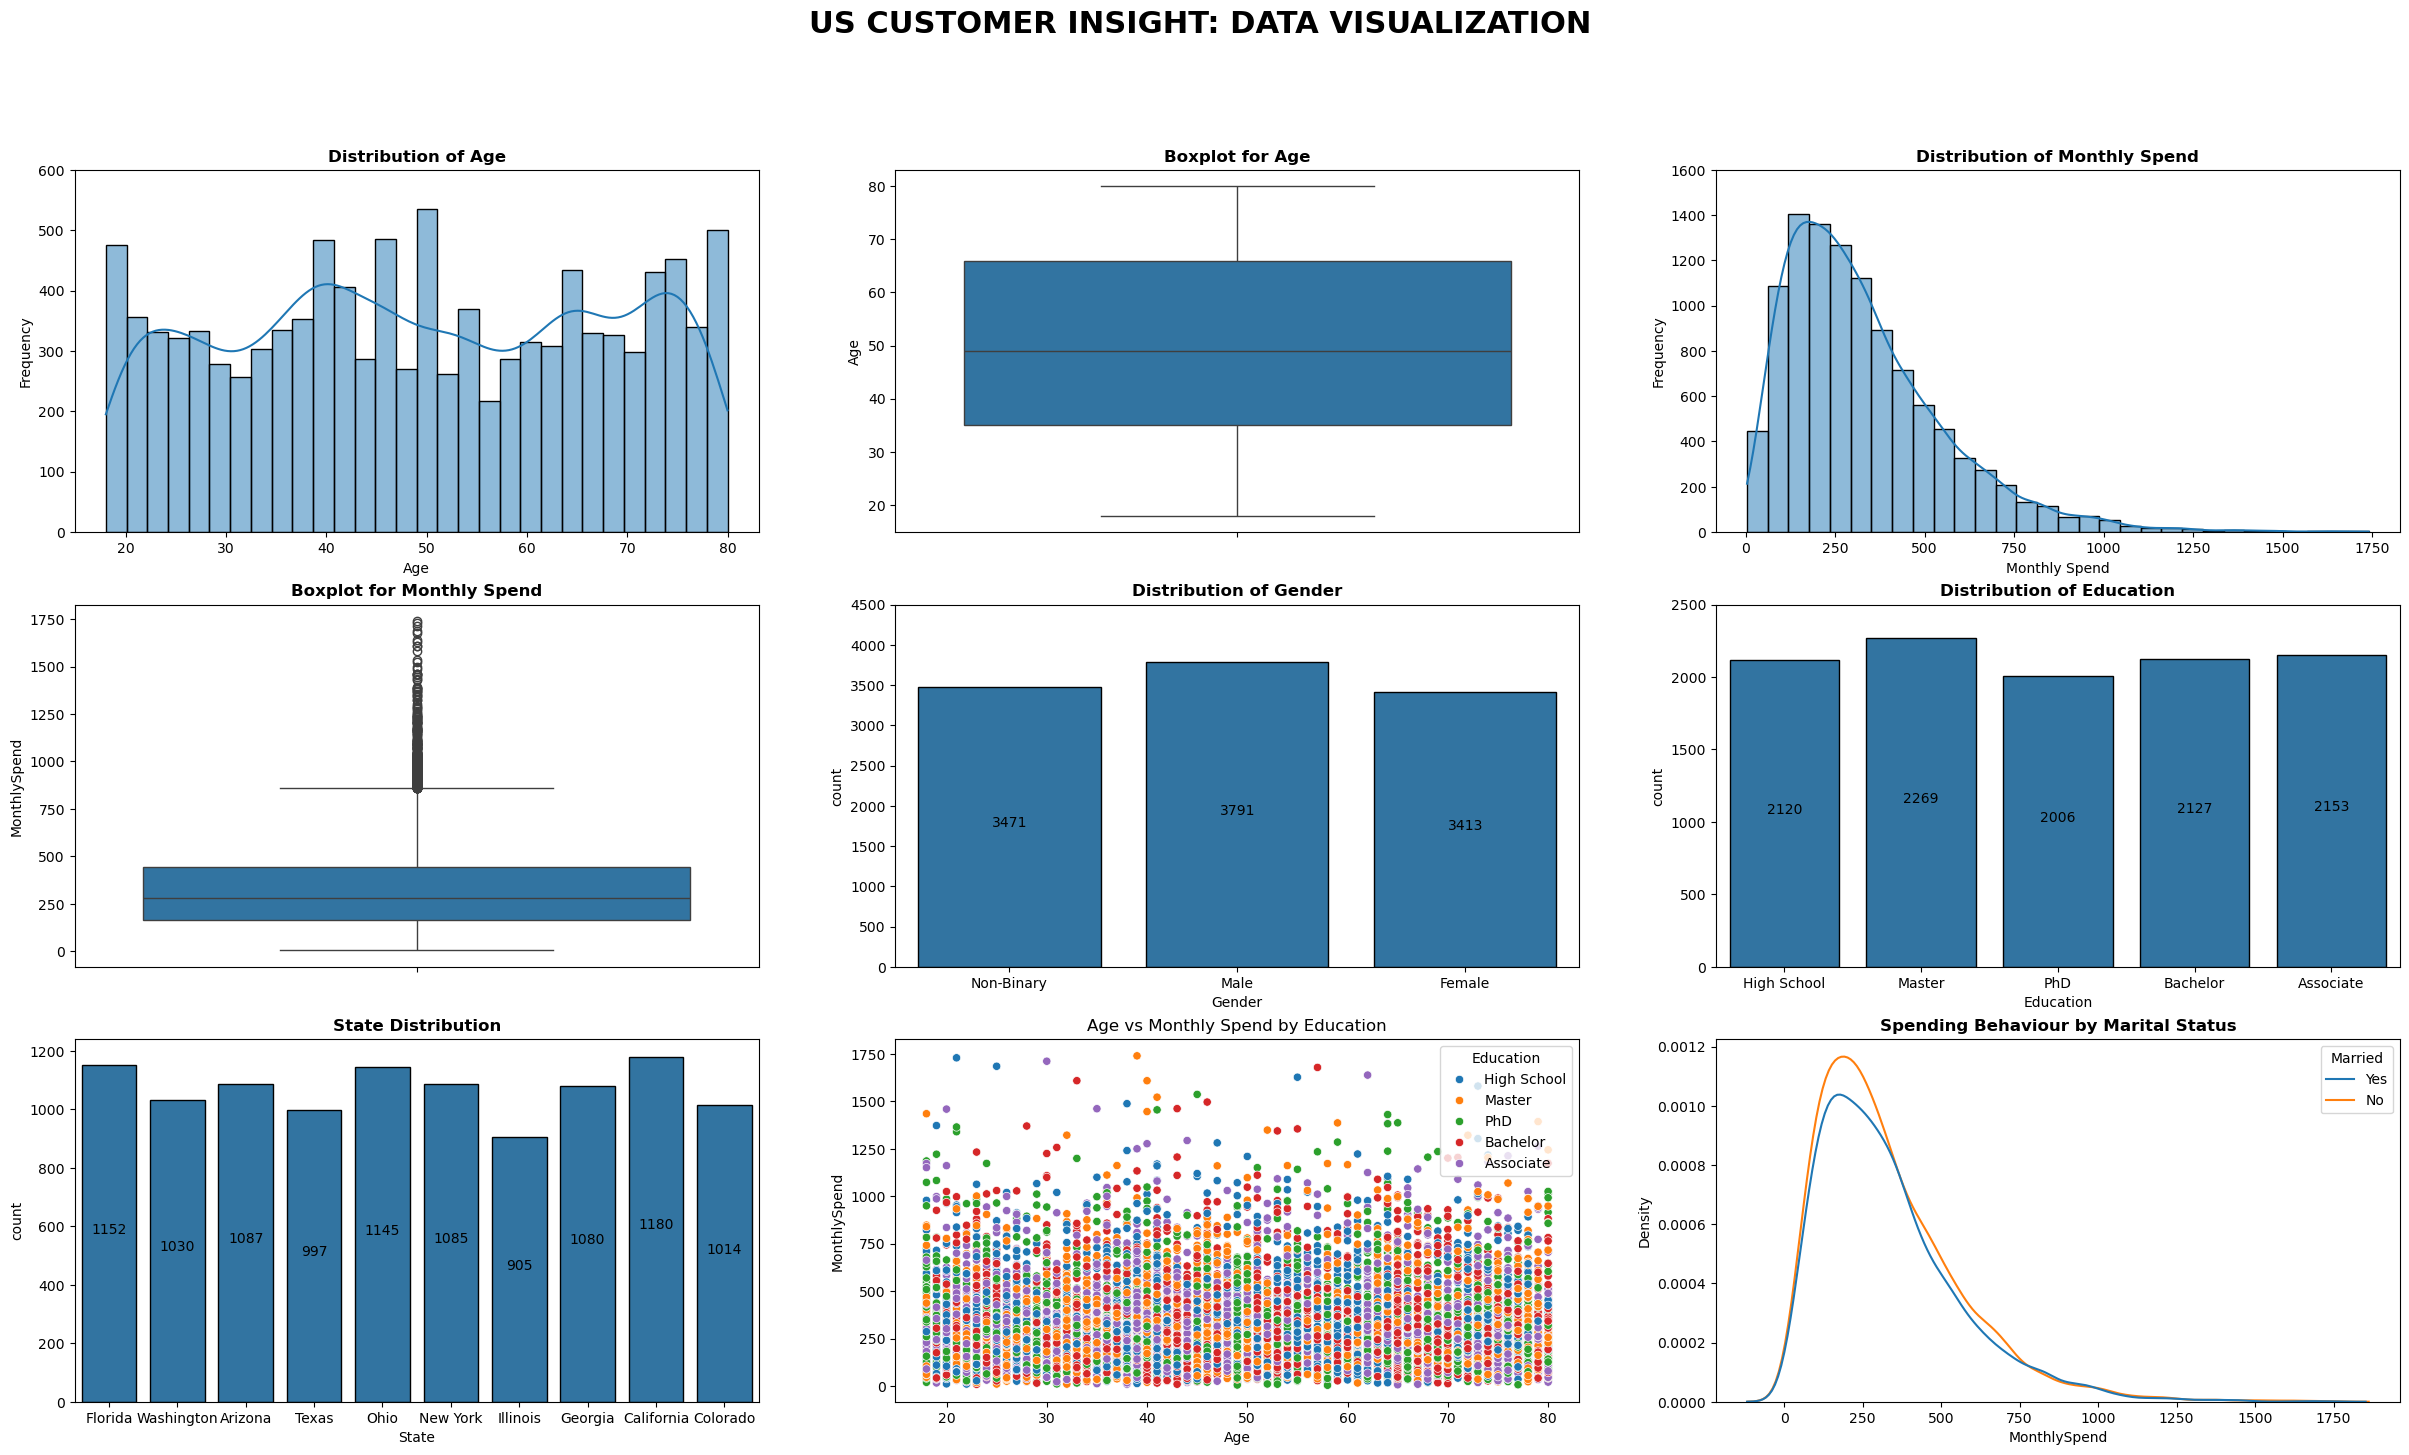

In [24]:
plt.figure(figsize=(30,16))
plt.suptitle("US CUSTOMER INSIGHT: DATA VISUALIZATION",fontweight='bold',fontsize=22)

# Histogram for Age
plt.subplot(3,3,1)
sns.histplot(x='Age',data=df_customers,bins=30,kde=True)
plt.title("Distribution of Age", fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.ylim(0,600)

# Boxplot for age
plt.subplot(3,3,2)
sns.boxplot(y="Age",data=df_customers)
plt.title("Boxplot for Age", fontweight='bold')

# Histogram for Monthly Spend
plt.subplot(3,3,3)
sns.histplot(x='MonthlySpend',data=df_customers,bins=30,kde=True)
plt.title("Distribution of Monthly Spend", fontweight='bold')
plt.xlabel("Monthly Spend")
plt.ylabel("Frequency")
plt.ylim(0,1600)

# Boxplot for Monthly Spend
plt.subplot(3,3,4)
sns.boxplot(y="MonthlySpend",data=df_customers)
plt.title("Boxplot for Monthly Spend", fontweight='bold')

# Bar chart for Gender
plt.subplot(3,3,5)
sns.countplot(x="Gender", data=df_customers, edgecolor="black")
plt.title("Distribution of Gender",fontweight='bold')
counts = df_customers["Gender"].value_counts(sort=False)
for i in range(len(counts)):
    plt.text(i, counts[i]/2, counts[i], ha="center")
plt.ylim(0, 4500)

# Bar chart for Education
plt.subplot(3,3,6)
sns.countplot(x="Education",data=df_customers,edgecolor="black")
plt.title("Distribution of Education",fontweight='bold')
plt.ylim(0,2500)
count_ed=df_customers["Education"].value_counts(sort=False)
for i in range(len(count_ed)):
    plt.text(i,count_ed[i]/2,count_ed[i],ha="center")

#Bar Chart for State
plt.subplot(3,3,7)
sns.countplot(x="State",data=df_customers,edgecolor='black')
plt.title("State Distribution",fontweight="bold")
count_state=df_customers['State'].value_counts(sort=False)
for i in range(len(count_state)):
    plt.text(i,count_state[i]/2,count_state[i],ha="center")

# Scatterplot Age vs Monthly Spend
plt.subplot(3,3,8)
sns.scatterplot(data=df_customers,x="Age",y="MonthlySpend",hue="Education")
plt.title("Age vs Monthly Spend by Education")

# KDE plot Spending behavior by marital status
plt.subplot(3,3,9)
plt.subplot(3,3,9)
sns.kdeplot(x='MonthlySpend',data=df_customers,hue="Married",fill=False)

plt.title("Spending Behaviour by Marital Status", fontweight="bold")

plt.show()

***PLOT ANALYSIS:***

***PLOT 1: Histogram for Age- Customers are spread across all age groups from 18 to 80.Most customers are middle-aged, and there is no extreme concentration in just one age group.***

***PLOT 2: Boxplot for age-The typical customer age is around 49 years.There are no extreme unusual age values(outliers). The ages are fairly balanced.***

***PLOT 3: Histogram for Monthly Spend- Most customers spend a moderate amount monthly.A small number of customers spend very high amounts.***

***PLOT 4: Boxplot for Monthly Spend- Most customers spend on the lower to medium side.There are many high-spending customers shown as outliers.This means a small group contributes much higher spending.***

***PLOT 5: Bar chart for Gender- The number of Male, Female, and Non-Binary customers is fairly balanced. Male customers are slightly higher in number.***

***PLOT 6: Bar chart for Education- Customers come from a wide range of education levels. Master’s degree holders are slightly more common, but overall the education levels are quite evenly distributed.***

***PLOT 7:Bar Chart for State- Customers are spread across all listed states. Some states like California and Florida have slightly more customers, but the difference is not very large.***

***PLOT 8: Scatterplot Age vs Monthly Spend by education- There is no strong relationship between age and spending.People of all ages and education levels spend both low and high amounts. Education level does not clearly determine spending amount.***

***PLOT 9: KDE plot Spending behavior by marital status- Spending patterns of married and unmarried customers look very similar.
There is no major difference in how much they spend monthly.***

## STEP 4- BIVARIATE ANALYSIS

In [25]:
# Correlation matrix (numeric variables)
df_customers.corr(numeric_only=True)

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
Age,1.000000,-0.023035,-0.012323,-0.003970
NumPets,-0.023035,1.000000,0.020647,-0.055227
MonthlySpend,-0.012323,0.020647,1.000000,0.006081
DaysSinceLastInteraction,-0.003970,-0.055227,0.006081,1.000000


***OUTPUT ANALYSIS: The correlation matrix shows no strong relationships between the numerical variables, as all correlation values are close to zero. This indicates that customer spending and activity are not strongly influenced by age or number of pets.***

In [26]:
# Crosstab of Gender vs Married
pd.crosstab(df_customers["Gender"],df_customers["Married"])

Married,No,Yes
Gender,,
Female,1797,1616
Male,1892,1899
Non-Binary,1894,1577


***OUTPUT INSIGHTS: The crosstab shows that marital status is fairly evenly distributed across genders, with a slightly higher number of unmarried customers in female and non binary gender categories, whereas the number of males who are unmarried and married is almost same with married males slightly more than unmarried ones.***

In [27]:
#Grouped stats: average MonthlySpend by State, Education, Gender

print("="*50)
print("Average Monthly Spend by State")
print("="*50)
print(df_customers.groupby("State")["MonthlySpend"].mean())
print("="*50)

print()
print("="*50)
print("Average Monthly Spend by Education")
print("="*50)
print(df_customers.groupby("Education")["MonthlySpend"].mean())
print("="*50)

print()
print("="*50)
print("Average Monthly Spend by Gender")
print("="*50)
print(df_customers.groupby("Gender")["MonthlySpend"].mean())
print("="*50)

Average Monthly Spend by State
State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Illinois      332.589591
New York      332.151244
Ohio          340.187860
Texas         319.506770
Washington    329.444078
Name: MonthlySpend, dtype: float64

Average Monthly Spend by Education
Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64

Average Monthly Spend by Gender
Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64


***OUTPUT INSIGHTS: The output shows us that the average spend is fairly balanced among all the groups. As per the states, Arizona has the highest average spend, followed by Ohio. As per education, people with masters degree tend to spend little more than others and as per gender, male customers spend little more than other categories on an average***

## STEP 5: FORMULATE HYPOTHESIS and STEP 6: RUN HYPOTHESIS TESTS

***HYPOTHESIS TEST 1 (Independent T-Test): Do males and females spend differently?***

In [28]:
#Null Hypothesis(H0)- There is no difference in average MonthlySpend between males and females.
#Alternative Hypothesis(H1): There is a difference in average MonthlySpend between males and females.

#fetching monthly spend of customers by gender
male_spend = df_customers[df_customers["Gender"] == "Male"]["MonthlySpend"]
female_spend = df_customers[df_customers["Gender"] == "Female"]["MonthlySpend"]
#putting level of significance(alpha) to the standard value
alpha=0.05
t_test_statistics,p_value= ttest_ind(male_spend,female_spend)

print("T-Test_Statistics",t_test_statistics)
print("P_value",p_value)

if p_value<alpha:
    print("CONCLUSION: REJECT null hypothesis, male and female customers spend differently")
else:
    print("CONCLUSION: FAILED to REJECT null hypothesis, male and female customers do not spend differently")

T-Test_Statistics 0.3391730320232445
P_value 0.7344892727022859
CONCLUSION: FAILED to REJECT null hypothesis, male and female customers do not spend differently


***OUTPUT INSIGHT: The independent t-test shows that there is no statistically significant difference in monthly spending between male and female customers (p = 0.734 > 0.05). Therefore, gender does not appear to influence customer spending behavior.***

***HYPOTHESIS TEST 2 (One way ANOVA)- Does education level impact average monthly spend?***

In [29]:
#Null Hypothesis(H0)- Education Level does not have a significant impact on monthly spend
#Alternate Hypothesis(H1)- Education Level has a significant impact on monthly spend

#putting level of significance(alpha) to the standard value
alpha=0.05
#fetching the list of unique education qualifications of the customers
df_customers["Education"].unique()

#running hypothesis test
hs=df_customers[df_customers["Education"]=="High School"]["MonthlySpend"]
master=df_customers[df_customers["Education"]=="Master"]["MonthlySpend"]
phd=df_customers[df_customers["Education"]=="PhD"]["MonthlySpend"]
bachelor=df_customers[df_customers["Education"]=="Bachelor"]["MonthlySpend"]
associate=df_customers[df_customers["Education"]=="Associate"]["MonthlySpend"]

test_statistics_anova,p_value1= f_oneway(hs,master,phd,bachelor,associate)
print("Test_Statistics_Anova",test_statistics_anova)
print("P_value1",p_value1)

if p_value1<alpha:
    print("CONCLUSION: REJECT null hypothesis, Education Level has a significant impact on monthly spend")
else:
    print("CONCLUSION: FAILED to REJECT null hypothesis, Education Level does not have a significant impact on monthly spend")

Test_Statistics_Anova 0.22880668673709165
P_value1 0.922359467759936
CONCLUSION: FAILED to REJECT null hypothesis, Education Level does not have a significant impact on monthly spend


***OUTPUT INSIGHT: The one-way ANOVA test shows no statistically significant difference in average monthly spending across different education levels (p = 0.922 > 0.05). Therefore, education level does not appear to influence customer spending behavior.***

***HYPOTHESIS TEST 3 (Correlation Age vs DaysSinceLastInteraction)- Are older people less active?***

In [30]:
# Null Hypothesis(H0)- There is no significant correlation between Age and DaysSinceLastInteraction.
#Alternate Hypothesis(H1)-There is a significant correlation between Age and DaysSinceLastInteraction.

corr, p_value2 = pearsonr(df_customers["Age"],df_customers["DaysSinceLastInteraction"])
#putting level of significance(alpha) to the standard value
alpha = 0.05
print("Correlation Coefficient:", corr)
print("P-value:", p_value2)

if p_value2<alpha:
    print("CONCLUSION: REJECT null hypothesis — Age is significantly related to customer activity.")
else:
    print("CONCLUSION: FAILED to REJECT null hypothesis — Age is not significantly related to customer activity.")

Correlation Coefficient: -0.0039702301049550455
P-value: 0.6816905437300954
CONCLUSION: FAILED to REJECT null hypothesis — Age is not significantly related to customer activity.


***OUTPUT ANALYSIS: The correlation test shows no statistically significant relationship between age and days since last interaction (r = -0.004, p = 0.682). Therefore, age does not significantly impact customer activity levels.***

***HYPOTHESIS TEST 4 (ANOVA) Does state-wise spend vary significantly?***

In [31]:
# Null Hypothesis(H0)- State wise spend does not vary significantly
# Alternate Hypothesis(H1)- State wise spend varies significantly 

#getting the list of states in the dataset
df_customers["State"].unique()

#putting level of significance(alpha) to the standard value
alpha=0.05

#fetching the monthly spend of customers across all states
florida=df_customers[df_customers["State"]=="Florida"]["MonthlySpend"]
washington=df_customers[df_customers["State"]=="Washington"]["MonthlySpend"]
arizona=df_customers[df_customers["State"]=="Arizona"]["MonthlySpend"]
texas=df_customers[df_customers["State"]=="Texas"]["MonthlySpend"]
ohio=df_customers[df_customers["State"]=="Ohio"]["MonthlySpend"]
new_york=df_customers[df_customers["State"]=="New York"]["MonthlySpend"]
illinois=df_customers[df_customers["State"]=="Illinois"]["MonthlySpend"]
georgia=df_customers[df_customers["State"]=="Georgia"]["MonthlySpend"]
california=df_customers[df_customers["State"]=="California"]["MonthlySpend"]
colorado=df_customers[df_customers["State"]=="Colorado"]["MonthlySpend"]

#running hypothesis test
test_st_anova,p_value3= f_oneway(florida,washington,arizona,texas,ohio,new_york,illinois,georgia,california,colorado)
print("Test stats ANOVA",test_st_anova)
print("P Value",p_value3)

if p_value3<alpha:
    print("CONCLUSION: REJECT null hypothesis, there is significant variation in statewise monthyspend")
else:
    print("CONCLUSION: FAILED to REJECT null hypothesis, there is no significant variation in statewise monthlyspend")

Test stats ANOVA 1.1178423640877182
P Value 0.34571886479238273
CONCLUSION: FAILED to REJECT null hypothesis, there is no significant variation in statewise monthlyspend


***OUTPUT INSIGHT: The one-way ANOVA test indicates that there is no statistically significant difference in average monthly spending across states (p = 0.346 > 0.05). Therefore, customer spending behavior does not significantly vary by state.***

## STEP 7: PRESENT BUSINESS INSIGHTS

***Spending differences based on education level***

In [32]:
df_customers.groupby("Education")["MonthlySpend"].mean()

Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64

***Business Insight- Customers with a Master’s degree spend little more per month than other customers. However, the overall difference across education levels is minimal, suggesting that education alone does not strongly influence spending behavior.”***

***Strategic Recommendations- Since spending differences across education groups are marginal, the company should prioritize behavioral segmentation (such as purchase frequency and recency) rather than relying heavily on education-based targeting.***

***Mothly spending based on marietal status***

In [33]:
married_means = df_customers.groupby("Married")["MonthlySpend"].mean()
married_means

Married
No     330.937184
Yes    332.348352
Name: MonthlySpend, dtype: float64

***Business Insights- Married customers spend approximately 0.43% more per month than unmarried customers. However, the difference is minimal, indicating that marital status has negligible influence on customer spending behavior.***

***Strategic Recommendations- Since marital status has negligible influence on spending, marketing teams should avoid segmenting campaigns by marital status. Instead, focus budget and targeting efforts on higher-impact variables such as state-level variability or customer engagement levels.***

***State-Level Spending Variability Analysis***

In [34]:
df_customers.groupby("State")["MonthlySpend"].std()

State
Arizona       243.710210
California    232.387167
Colorado      211.540852
Florida       214.882315
Georgia       217.601012
Illinois      216.812288
New York      224.249336
Ohio          243.167936
Texas         215.458625
Washington    231.346449
Name: MonthlySpend, dtype: float64

***Business Insights-Arizona exhibits the highest spending variability (std = 243.71), while Colorado shows the lowest variability (std = 211.54). This indicates that customer purchasing behavior is more diverse in Arizona compared to more stable and predictable spending patterns in Colorado.***

***Strategic recommendation-In high-variability states like Arizona, personalized and segmented marketing campaigns may improve targeting effectiveness. In more stable states like Colorado, standardized promotional strategies may be more efficient.***

***Customer Engagement***

In [35]:
print(df_customers["DaysSinceLastInteraction"].mean())
print(df_customers["DaysSinceLastInteraction"].min())
print(df_customers["DaysSinceLastInteraction"].max())

538.4698829039812
1
1791


***Business Insights-Customer engagement levels vary significantly. While the most active customer interacted just 1 day ago, the most inactive customer has not engaged for nearly 5 years (1791 days). The overall average inactivity of 538 days (around 1.5 years) indicates that many customers may be at risk of becoming inactive or discontinuing their relationship with the company.***

***Strategic recommendation-The company should implement a tiered engagement strategy: Recently active customers (low days) → Reward with loyalty perks and personalized offers to maintain engagement. Moderately inactive customers (~1–2 years) → Target with reminder emails and promotional incentives. Highly inactive customers (3+ years) → Launch reactivation campaigns or evaluate whether to remove long-unresponsive customers from marketing efforts to improve efficiency.***

<div align="center">

# **END OF REPORT**

</div>